# Clustering Analysis of Data Science Salaries
Group 2, Prince Newman

Can we identify natural groups of data science jobs based on compensation, seniority, work arrangement, and company size?
This is interesting because it moves beyond salary alone and asks whether jobs naturally cluster into career tiers that reflect real industry patterns, for example whether high salary jobs consistently align with senior experience and large companies, or whether remote work cuts across all tiers.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

## Part 1

In [4]:
# Load data
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset shape: (3191, 12)

Columns: ['ID', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


Data Preparation

In [7]:
# Encode categorical variables
# experience_level has a natural order: EN < MI < SE < EX
exp_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}  # encoding as 1,2,3,4 preserves that order meaningfully
df['experience_encoded'] = df['experience_level'].map(exp_map)

# company_size has a natural order: S < M < L
size_map = {'S': 1, 'M': 2, 'L': 3}
df['size_encoded'] = df['company_size'].map(size_map)

# variables for clustering
cluster_vars = ['salary_in_usd', 'experience_encoded',
                'remote_ratio', 'size_encoded']

# Drop any rows with missing values in these columns
df_cluster = df[cluster_vars].dropna().reset_index(drop=True)

print(f"\nClustering dataset shape: {df_cluster.shape}")
print(f"\nClustering dataset shape: {df_cluster.shape}")
print(f"\nVariables included:")
print(f"  salary_in_usd: compensation in USD (numeric)")
print(f"  experience_encoded: seniority EN=1, MI=2, SE=3, EX=4")
print(f"  remote_ratio: work arrangement 0/50/100")
print(f"  size_encoded: company size S=1, M=2, L=3")
print(f"\nDescriptive statistics:")

df_cluster.describe().round(2)



Clustering dataset shape: (3191, 4)

Clustering dataset shape: (3191, 4)

Variables included:
  salary_in_usd: compensation in USD (numeric)
  experience_encoded: seniority EN=1, MI=2, SE=3, EX=4
  remote_ratio: work arrangement 0/50/100
  size_encoded: company size S=1, M=2, L=3

Descriptive statistics:


,salary_in_usd,experience_encoded,remote_ratio,size_encoded
count,3191.00,3191.00,3191.00,3191.00
mean,129393.41,2.54,54.37,2.12
std,68372.80,0.74,47.51,0.50
min,2859.00,1.00,0.00,1.00
25%,80000.00,2.00,0.00,2.00
50%,124234.00,3.00,50.00,2.00
75%,170000.00,3.00,100.00,2.00
max,600000.00,4.00,100.00,3.00


In [8]:
# Standardize
# Salary is in hundreds of thousands while other variables
# are on scales of 1-4 or 0-100.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_vars)

print("After standardization (mean ~0, std ~1):")
X_scaled_df.describe().round(3)

After standardization (mean ~0, std ~1):


,salary_in_usd,experience_encoded,remote_ratio,size_encoded
count,3191.000,3191.000,3191.000,3191.000
mean,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.851,-2.076,-1.145,-2.244
25%,-0.723,-0.727,-1.145,-0.237
50%,-0.075,0.622,-0.092,-0.237
75%,0.594,0.622,0.960,-0.237
max,6.884,1.971,0.960,1.770


Standardization was applied to all four variables to ensure they contribute equally to the clustering analysis. Each variable now has a mean of zero and a standard deviation of one, meaning salary is no longer measured in hundreds of thousands but on the same scale as experience, remote ratio, and company size. One notable observation is that the maximum salary value of 6.884 standard deviations above the mean indicates the presence of high salary outliers in the dataset, likely reflecting senior US based roles. The 25th through 75th percentile values for remote ratio and company size are very similar, suggesting most jobs in the dataset share comparable work arrangements and company sizes, with salary and experience level carrying more of the meaningful variation for clustering.

## PART 2: K-Means Clustering


In [9]:
# Elbow method
# Try K from 2 to 10
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f"K={k} | Inertia: {km.inertia_:>10.2f} | "
          f"Silhouette: {sil:.4f}")

K=2 | Inertia:    9463.15 | Silhouette: 0.2815
K=3 | Inertia:    7277.91 | Silhouette: 0.3323
K=4 | Inertia:    5708.43 | Silhouette: 0.3757
K=5 | Inertia:    4963.38 | Silhouette: 0.3654
K=6 | Inertia:    4324.43 | Silhouette: 0.4088
K=7 | Inertia:    3824.89 | Silhouette: 0.4061
K=8 | Inertia:    3329.96 | Silhouette: 0.4306
K=9 | Inertia:    2971.78 | Silhouette: 0.4075
K=10 | Inertia:    2763.36 | Silhouette: 0.4104


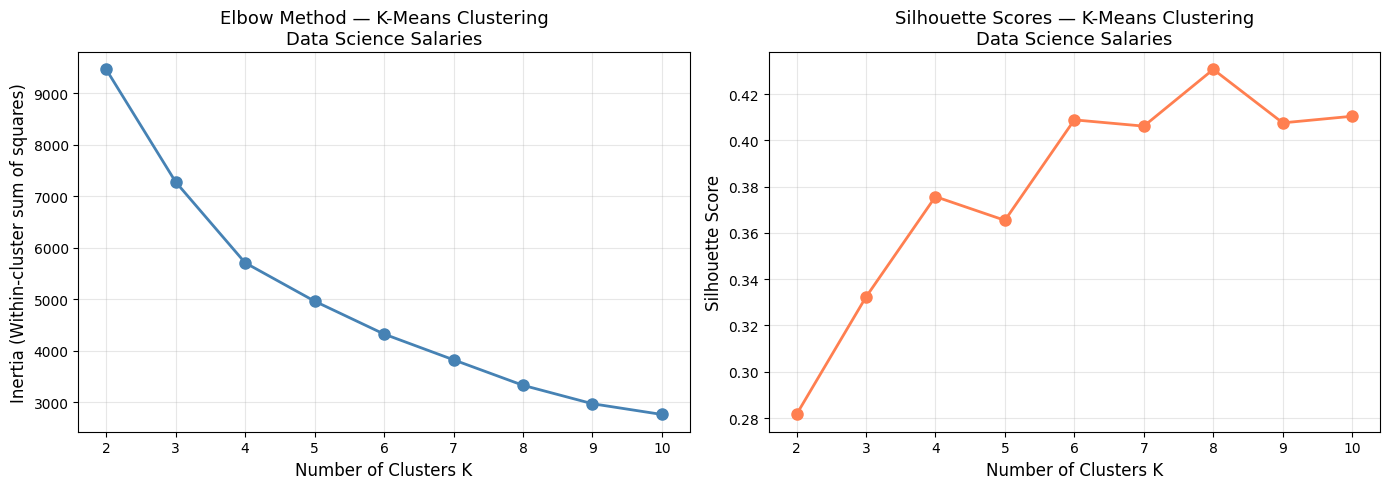


Best K by silhouette score: 8
Silhouette score at K=8: 0.4306


In [12]:
# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(list(K_range), inertias, 'o-',
         color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters K', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method — K-Means Clustering\nData Science Salaries',
              fontsize=13)
ax1.set_xticks(list(K_range))
ax1.grid(alpha=0.3)


# Silhouette plot
ax2.plot(list(K_range), silhouette_scores, 'o-',
         color='coral', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters K', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Scores — K-Means Clustering\nData Science Salaries',
              fontsize=13)
ax2.set_xticks(list(K_range))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K by silhouette score: {best_k}")
print(f"Silhouette score at K={best_k}: {max(silhouette_scores):.4f}")

In [13]:
# Fit final K-means with best K
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

# Profile each cluster
print(f"\nCluster profiles (K={best_k}):")
print("="*65)
profile = df_cluster.groupby('cluster')[cluster_vars].mean()

# Add back original scale for interpretability
profile_orig = pd.DataFrame(
    scaler.inverse_transform(
        scaler.fit_transform(df_cluster[cluster_vars])
    ),
    columns=cluster_vars
)
profile_orig['cluster'] = df_cluster['cluster']
print(profile_orig.groupby('cluster').mean().round(2))

print("\nCluster sizes:")
print(df_cluster['cluster'].value_counts().sort_index())


Cluster profiles (K=8):
         salary_in_usd  experience_encoded  remote_ratio  size_encoded
cluster                                                               
0             78461.53                1.73         92.71          2.00
1            135719.33                3.05          0.98          1.99
2            139785.90                3.03         63.35          3.00
3            108027.16                1.83          0.42          2.00
4            151618.58                3.03         99.94          1.98
5            276218.82                3.03         21.70          2.11
6             63003.41                1.86         72.06          1.00
7             76414.48                1.62         68.81          3.00

Cluster sizes:
cluster
0    350
1    665
2    251
3    356
4    826
5    212
6    204
7    327
Name: count, dtype: int64


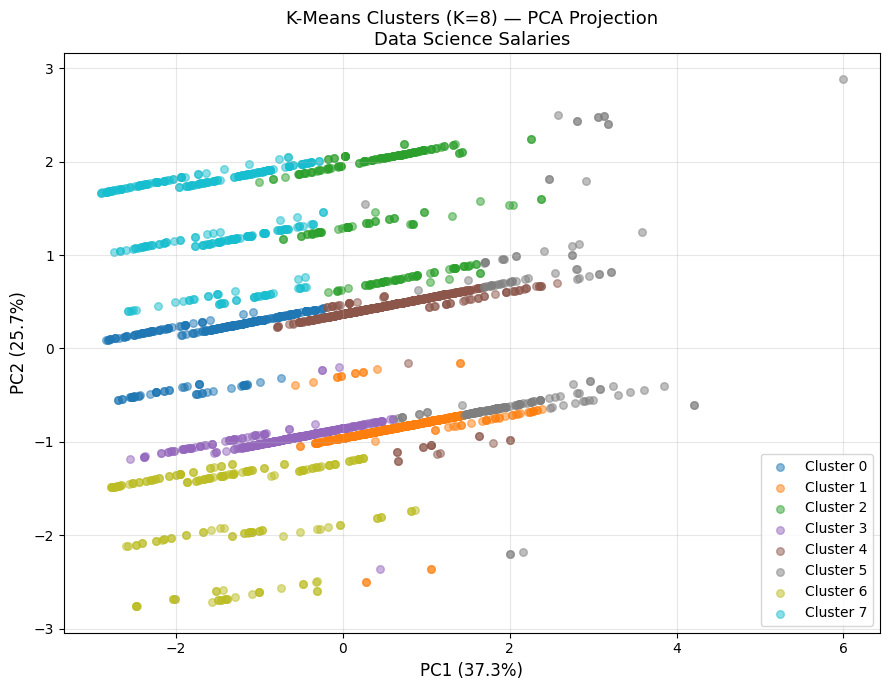

In [14]:
# Visualize clusters using PCA
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for k in range(best_k):
    mask = df_cluster['cluster'] == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colors[k], alpha=0.5, s=30,
               label=f'Cluster {k}')

ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)',
              fontsize=12)
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)',
              fontsize=12)
ax.set_title(f'K-Means Clusters (K={best_k}) — PCA Projection\n'
             f'Data Science Salaries', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

Obswrvation: The elbow plot shows inertia decreasing steadily across all values of K without a sharp bend, suggesting the data has a gradual rather than obvious cluster structure. The silhouette scores provide clearer guidance, peaking at K=8 with a score of 0.43, which is why K=8 was selected as the optimal number of clusters. Looking at the cluster profiles, the eight groups reveal genuinely distinct job tiers, Cluster 5 stands out as the highest compensation group averaging USD 276,219 with senior experience, while Cluster 6 sits at the lowest end at USD63,003 with small company size. The remaining clusters fall in between and differ meaningfully in their combination of salary, experience level, remote ratio, and company size, confirming that natural groupings exist in the data science job market beyond salary alone. The PCA projection visually confirms this separation, with clusters spreading diagonally across the plot reflecting the joint influence of compensation and seniority.

## PART 3: Hierarchical Clustering


In [16]:
# Sample 100 observations for clear dendrogram visualization
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 150, replace=False)
X_sample = X_scaled[sample_idx]

# Linkage method 1: Ward minimizes the total within-cluster variance at each step, produces compact, evenly sized clusters
Z_ward = linkage(X_sample, method='ward')

# Linkage method 2: Complete linkage uses the maximum distance between clusters
Z_complete = linkage(X_sample, method='complete')

print(f"Sample size used for dendrograms: {len(X_sample)}")

Sample size used for dendrograms: 150


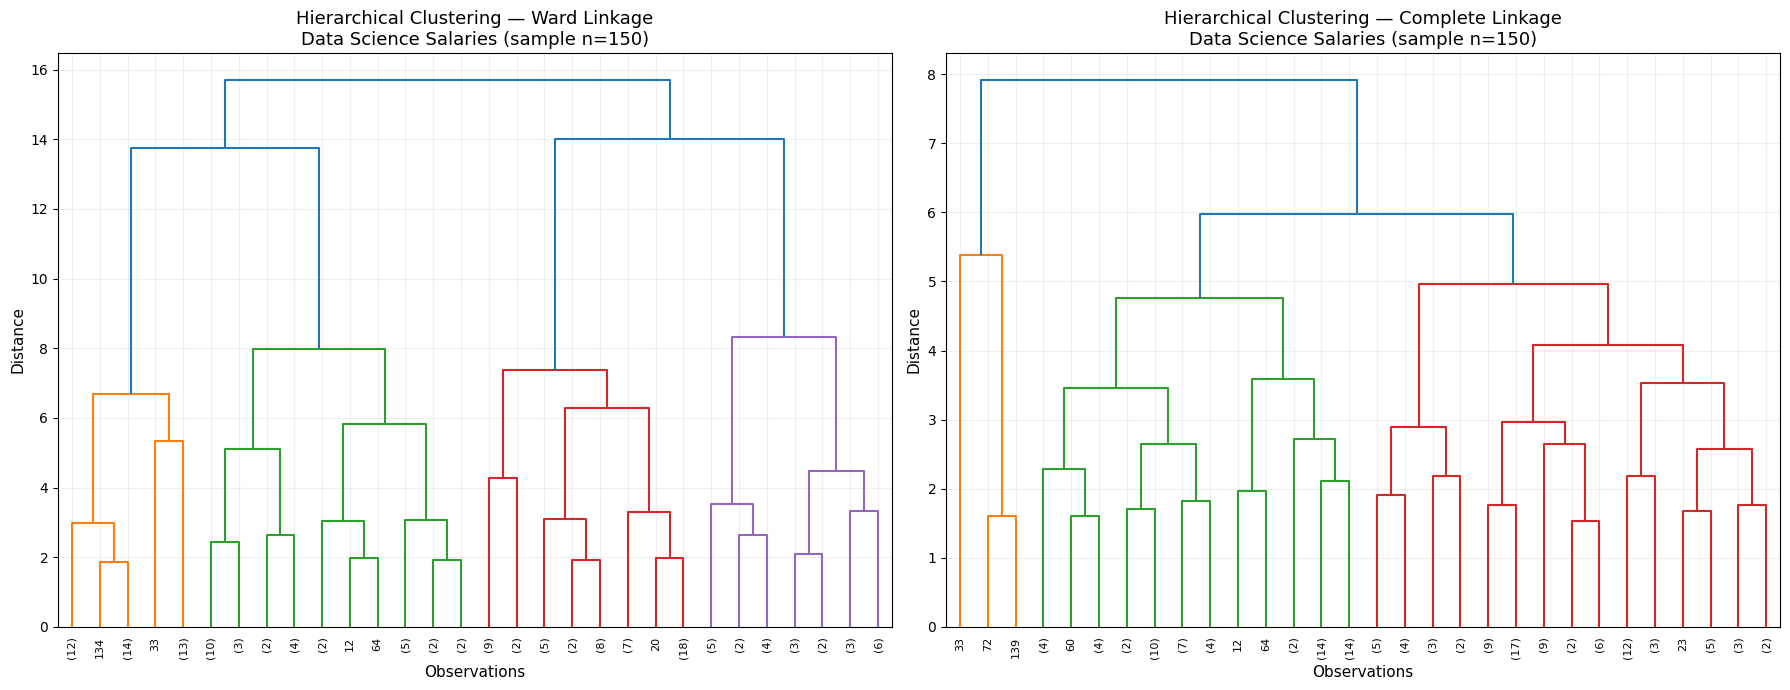

In [17]:
# Plot dendrograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Ward dendrogram
dendrogram(Z_ward,
           ax=ax1,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=0.7 * max(Z_ward[:, 2]))
ax1.set_title('Hierarchical Clustering — Ward Linkage\n'
              'Data Science Salaries (sample n=150)', fontsize=13)
ax1.set_xlabel('Observations', fontsize=11)
ax1.set_ylabel('Distance', fontsize=11)
ax1.grid(alpha=0.2)

# Complete dendrogram
dendrogram(Z_complete,
           ax=ax2,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=0.7 * max(Z_complete[:, 2]))
ax2.set_title('Hierarchical Clustering — Complete Linkage\n'
              'Data Science Salaries (sample n=150)', fontsize=13)
ax2.set_xlabel('Observations', fontsize=11)
ax2.set_ylabel('Distance', fontsize=11)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('dendrograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Cut the dendrogram and compare to K-means
n_clusters_hier = best_k

ward_labels    = fcluster(Z_ward,    n_clusters_hier, criterion='maxclust')
complete_labels = fcluster(Z_complete, n_clusters_hier, criterion='maxclust')

# Silhouette scores for hierarchical methods
sil_ward     = silhouette_score(X_sample, ward_labels)
sil_complete = silhouette_score(X_sample, complete_labels)
sil_kmeans   = silhouette_score(X_sample,
                                km_final.predict(X_sample))

print(f"\nSilhouette score comparison (n=150 sample, K={best_k}):")
print(f"  Ward linkage:     {sil_ward:.4f}")
print(f"  Complete linkage: {sil_complete:.4f}")
print(f"  K-means:          {sil_kmeans:.4f}")

print(f"\nWard cluster sizes:")
print(pd.Series(ward_labels).value_counts().sort_index())
print(f"\nComplete cluster sizes:")
print(pd.Series(complete_labels).value_counts().sort_index())


Silhouette score comparison (n=150 sample, K=8):
  Ward linkage:     0.3688
  Complete linkage: 0.3255
  K-means:          0.4185

Ward cluster sizes:
1    27
2    14
3    19
4    13
5    11
6    41
7    11
8    14
Name: count, dtype: int64

Complete cluster sizes:
1     2
2     1
3    32
4     2
5    30
6    14
7    43
8    26
Name: count, dtype: int64


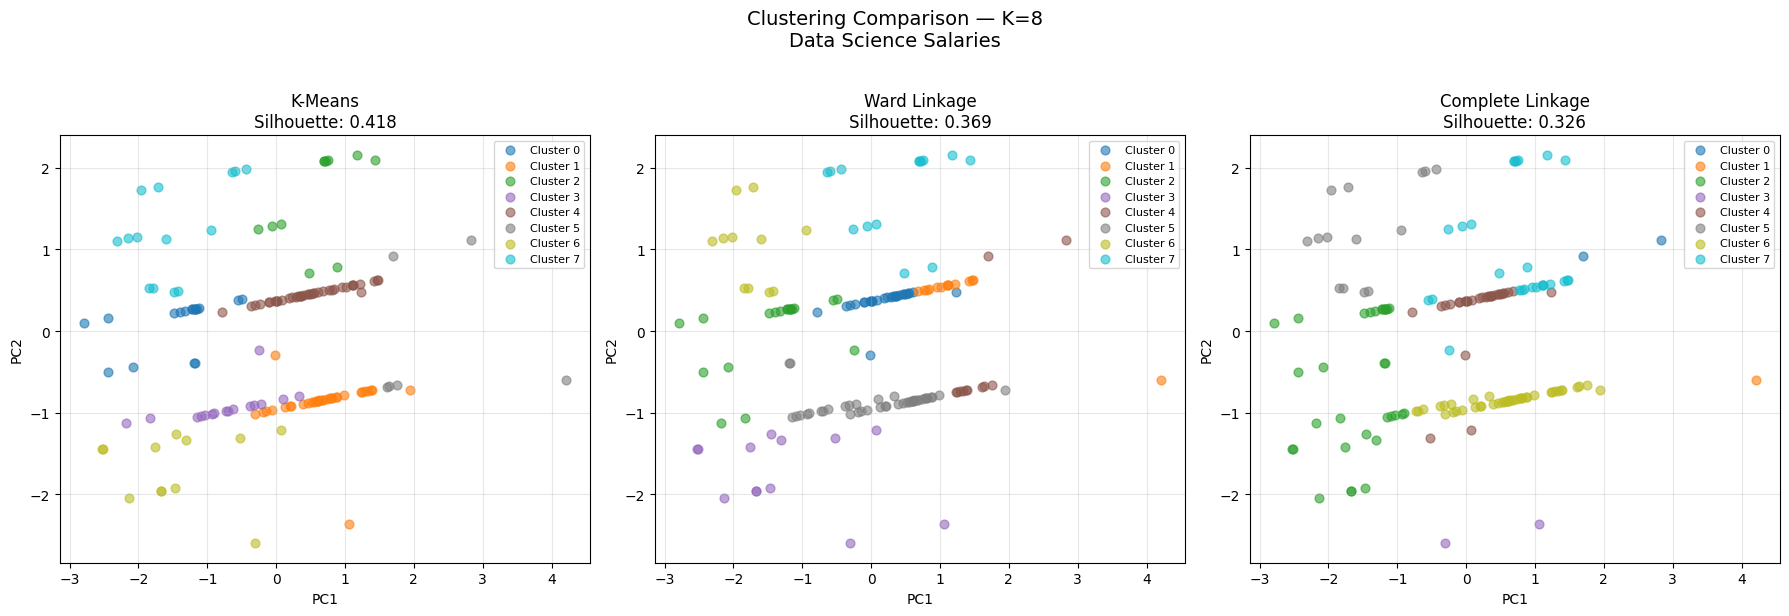

In [19]:
# Final comparison plot
X_sample_pca = pca_viz.transform(X_sample)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['K-Means', 'Ward Linkage', 'Complete Linkage']
all_labels = [
    km_final.predict(X_sample),
    ward_labels - 1,
    complete_labels - 1
]

for ax, title, labels in zip(axes, titles, all_labels):
    colors = plt.cm.tab10(np.linspace(0, 1, best_k))
    for k in range(best_k):
        mask = labels == k
        ax.scatter(X_sample_pca[mask, 0],
                   X_sample_pca[mask, 1],
                   color=colors[k], alpha=0.6,
                   s=40, label=f'Cluster {k}')
    ax.set_title(f'{title}\nSilhouette: '
                 f'{silhouette_score(X_sample, labels):.3f}',
                 fontsize=12)
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Clustering Comparison — K={best_k}\nData Science Salaries',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Both dendrograms suggest the data separates into a small number of broad groups at the top level with finer subdivisions below. Ward linkage produces more balanced cluster sizes averaging around 19 observations per cluster, while complete linkage is more sensitive to outliers, producing one group of 43 and two groups of just 1 and 2 observations. Comparing silhouette scores, K-means performs best at 0.419, followed by Ward at 0.369 and complete linkage at 0.326, making Ward the preferred hierarchical method as it produces the most balanced and interpretable groupings most consistent with the K-means result.

### Concluding non-technical Interpretation

In simple terms, the analysis found that data science jobs naturally fall into distinct groups based on how much they pay, how senior the role is, whether it is remote, and the size of the company. The most interesting finding is that salary alone does not define these groups; two jobs can pay similarly but belong to different groups because one is fully remote at a small company while the other is on-site at a large company. At the top end, there is a clear high compensation tier averaging over USD276,000 that consistently pairs senior experience with established companies. At the bottom end, there is a group averaging around $63,000 that tends to be early career roles at small companies. In between there are six other distinct profiles that capture the variety of arrangements in the data science job market. The practical takeaway for someone navigating a data science career is that your compensation is shaped not just by your skill level but by the combination of the company you work for, how senior your role is, and whether the position is remote, and these factors cluster together in predictable patterns across the industry.